[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/cvilelahep/LIP_Internships26_SNDATLAS/blob/main/to_df.ipynb)

In [30]:
import numpy as np
import uproot
import matplotlib.pyplot as plt
import pandas as pd
import awkward as ak

In [31]:
signal = uproot.open("Data/filtered_signal_v2_eta.root:Events")
background = uproot.open("Data/filtered_background_v2_eta.root:Events")

signal.show()


name                 | typename                 | interpretation                
---------------------+--------------------------+-------------------------------
npdg                 | int32_t                  | AsDtype('>i4')
pdg                  | int64_t[]                | AsJagged(AsDtype('>i8'))
ncharge              | int32_t                  | AsDtype('>i4')
charge               | double[]                 | AsJagged(AsDtype('>f8'))
npx                  | int32_t                  | AsDtype('>i4')
px                   | double[]                 | AsJagged(AsDtype('>f8'))
mpx                  | double                   | AsDtype('>f8')
npy                  | int32_t                  | AsDtype('>i4')
py                   | double[]                 | AsJagged(AsDtype('>f8'))
mpy                  | double                   | AsDtype('>f8')
npz                  | int32_t                  | AsDtype('>i4')
pz                   | double[]                 | AsJagged(AsDtype('>f8'))
mpz     

In [32]:
#signal.show()
signal_df = pd.DataFrame()
signal_df["n"] = 0.0

n = 0
for event in signal["npt"].array():
  signal_df._set_value(index=n, col="n", value = event)
  n+=1

for key in signal.keys():

  if key.startswith("n") or key.startswith("m") or key.startswith("charge") or key.startswith("pdg"): continue


  for i in range(1, 4):
    signal_df[key + str(i)] = 0.0
    

  n = 0
  for event in signal[key].array():
      
    for j in range(0, min(3,len(event))):

      signal_df._set_value(index=n, col=key + str(j+1), value = event[j])

    n += 1
#signal_df._set_value(index=n, col=key + str(i), value = event[j])

#signal_df["mpt"] = signal["mpt"].array()
signal_df["nu_eta"] = signal["nu_eta"].array()
signal_df["nu_phi"] = signal["nu_phi"].array()
signal_df["nu_E"] = signal["nu_E"].array()


signal_df["dphi2"] = signal_df["phi2"] - signal_df["phi1"]
signal_df["dphi3"] = signal_df["phi3"] - signal_df["phi1"]
signal_df["p1"] = np.sqrt(signal_df["px1"]**2 + signal_df["py1"]**2 + signal_df["pz1"]**2)
signal_df["p2"] = np.sqrt(signal_df["px2"]**2 + signal_df["py2"]**2 + signal_df["pz2"]**2)
signal_df["p3"] = np.sqrt(signal_df["px3"]**2 + signal_df["py3"]**2 + signal_df["pz3"]**2)
signal_df["nu_dphi1"] = signal_df["phi1"] - signal_df["nu_phi"]
signal_df["nu_dphi2"] = signal_df["phi2"] - signal_df["nu_phi"]
signal_df["nu_dphi3"] = signal_df["phi3"] - signal_df["nu_phi"]


signal_df = signal_df.fillna(0) 
signal_df.head()


,n,px1,px2,px3,py1,py2,py3,pz1,pz2,pz3,...,nu_phi,nu_E,dphi2,dphi3,p1,p2,p3,nu_dphi1,nu_dphi2,nu_dphi3
0,23.0,0.341302,0.423121,0.712901,-1.161581,0.598600,0.130147,-6.847215,-1.083765,-4.577632,...,-2.530705,287.443175,2.240502,1.465586,6.953424,1.308395,4.634639,1.245691,3.486193,2.711277
1,9.0,-0.664505,0.827812,-0.730192,-0.642867,-0.117435,0.159215,2.425553,1.640993,-0.341551,...,1.041283,153.308714,2.231822,5.299652,2.595795,1.841717,0.821698,-3.414026,-1.182204,1.885625
2,10.0,0.455043,-0.426180,-0.076348,0.466586,0.457529,0.595201,3.893817,-2.613973,4.141468,...,0.295981,155.135097,1.522813,0.900450,3.947984,2.687716,4.184716,0.501941,2.024754,1.402391
3,10.0,0.897833,0.311033,-0.797256,-0.757104,1.005055,-0.251378,0.472911,22.820831,0.803065,...,-0.761616,187.137241,1.971242,-2.135589,1.266079,22.845070,1.159190,0.061049,2.032291,-2.074539
4,12.0,-0.959030,-0.842865,0.623441,-0.023885,0.446062,-0.455442,-10.125958,16.949891,3.468552,...,-2.795482,897.863595,5.771534,2.485769,10.171300,16.976696,3.553443,-0.321210,5.450325,2.164559


In [33]:

#signal.show()
background_df = pd.DataFrame()
background_df["n"] = 0.0

n = 0
for event in background["npt"].array():
  background_df._set_value(index=n, col="n", value = event)
  n+=1

for key in background.keys():

  if key.startswith("n") or key.startswith("m") or key.startswith("charge") or key.startswith("pdg"): continue


  for i in range(1, 4):
    background_df[key + str(i)] = 0.0       

  n = 0
  for event in background[key].array():
    
    for j in range(0, min(3,len(event))):

      background_df._set_value(index=n, col=key + str(j+1), value = event[j])

    n += 1
#signal_df._set_value(index=n, col=key + str(i), value = event[j])


#background_df["mpt"] = background["mpt"].array()
background_df["nu_eta"] = background["nu_eta"].array()
background_df["nu_phi"] = background["nu_phi"].array()
background_df["nu_E"] = background["nu_E"].array()


background_df["dphi2"] = background_df["phi2"] - background_df["phi1"]
background_df["dphi3"] = background_df["phi3"] - background_df["phi1"]
background_df["p1"] = np.sqrt(background_df["px1"]**2 + background_df["py1"]**2 + background_df["pz1"]**2)
background_df["p2"] = np.sqrt(background_df["px2"]**2 + background_df["py2"]**2 + background_df["pz2"]**2)
background_df["p3"] = np.sqrt(background_df["px3"]**2 + background_df["py3"]**2 + background_df["pz3"]**2)
background_df["nu_dphi1"] = background_df["phi1"] - background_df["nu_phi"]
background_df["nu_dphi2"] = background_df["phi2"] - background_df["nu_phi"]
background_df["nu_dphi3"] = background_df["phi3"] - background_df["nu_phi"]

background_df = background_df.fillna(0) 
background_df.head()




,n,px1,px2,px3,py1,py2,py3,pz1,pz2,pz3,...,nu_phi,nu_E,dphi2,dphi3,p1,p2,p3,nu_dphi1,nu_dphi2,nu_dphi3
0,22.0,1.189763,0.840376,0.041751,0.077562,-0.177153,-0.829858,-1.606082,-0.505246,-12.063575,...,1.041283,153.308714,-0.272859,-1.585627,2.000263,0.996438,12.092156,-0.976183,-1.249043,-2.561810
1,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.295981,155.135097,0.000000,0.000000,0.000000,0.000000,0.000000,-0.295981,-0.295981,-0.295981
2,1.0,-0.723424,0.000000,0.000000,-0.322765,0.000000,0.000000,-2.281013,0.000000,0.000000,...,-0.761616,187.137241,2.721934,2.721934,2.414652,0.000000,0.000000,-1.960318,0.761616,0.761616
3,15.0,1.610713,-0.986182,0.572967,1.544951,-0.187255,-0.539161,-1.495349,4.662835,-2.066430,...,-2.795482,897.863595,-3.718510,-1.519572,2.686511,4.769659,2.211136,3.560044,-0.158466,2.040472
4,17.0,-0.144187,0.023804,-0.406996,-1.996183,1.478367,-0.676870,2.032728,2.009524,-10.365869,...,-0.610273,428.003820,3.197599,-0.469262,2.852634,2.494859,10.395914,-1.032629,2.164970,-1.501891


In [34]:
signal_df.tail()



,n,px1,px2,px3,py1,py2,py3,pz1,pz2,pz3,...,nu_phi,nu_E,dphi2,dphi3,p1,p2,p3,nu_dphi1,nu_dphi2,nu_dphi3
50879,15.0,-0.695763,-0.775099,-0.405069,0.871712,0.646611,-0.580245,-6.788004,-0.443236,17.559447,...,0.491709,39.767532,0.201913,-4.424659,6.879023,1.102426,17.573701,1.752704,1.954616,-2.671955
50880,47.0,0.855852,-0.386626,-0.627445,-1.070166,0.890484,0.714322,0.504450,-2.108482,1.379431,...,-1.251365,420.123670,2.876628,3.187753,1.460208,2.321236,1.675343,0.355149,3.231777,3.542902
50881,17.0,-1.149998,0.940758,0.707451,-0.509208,-0.556397,-0.803454,33.574087,7.078216,2.702671,...,2.639435,286.494025,2.190653,1.875897,33.597636,7.162104,2.906967,-5.364185,-3.173532,-3.488288
50882,26.0,-0.019004,-0.620973,-0.629583,-1.274193,1.083555,0.862627,-28.461260,-1.482770,3.585837,...,-2.771615,387.258790,3.676902,3.786982,28.489774,1.938634,3.741487,1.185906,4.862808,4.972888
50883,45.0,-2.014637,1.981646,1.392364,0.005895,-0.020648,-0.501691,-0.165124,-46.568650,-6.093445,...,0.556394,815.686208,-3.149085,-3.484502,2.021401,46.610798,6.270602,2.582272,-0.566813,-0.902230


In [35]:
signal_df["target"] = 1.
background_df["target"] = 0.
signal_df = signal_df.drop(columns=["phi1", "phi2", "phi3"])
background_df = background_df.drop(columns=["phi1", "phi2", "phi3"])


In [37]:
signal_df.to_csv("Data/signal_v2_eta_E.csv", index=False)
background_df.to_csv("Data/background_v2_eta_E.csv", index=False)

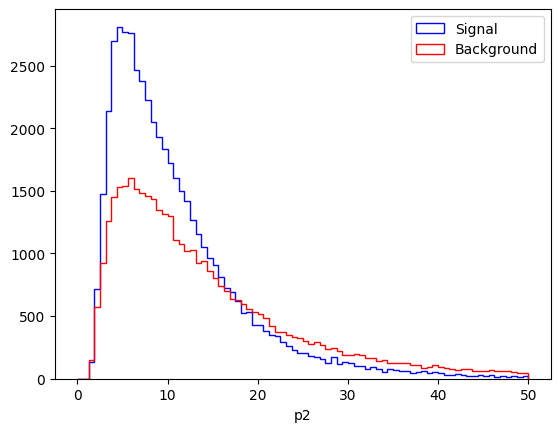

In [29]:

plt.figure()

plt.hist(
    signal_df["p2"][signal_df["p2"] != 0].dropna(),
    bins=80,
    range=(0, 50),
    histtype="step",
    linewidth=1,
    color="b",
    label="Signal"
)

plt.hist(
    background_df["p2"][background_df["p2"] != 0].dropna(),
    bins=80,
    range=(0, 50),
    histtype="step",
    linewidth=1,
    color="r",
    label="Background"
)

plt.xlabel("p2")
plt.legend()
plt.show()